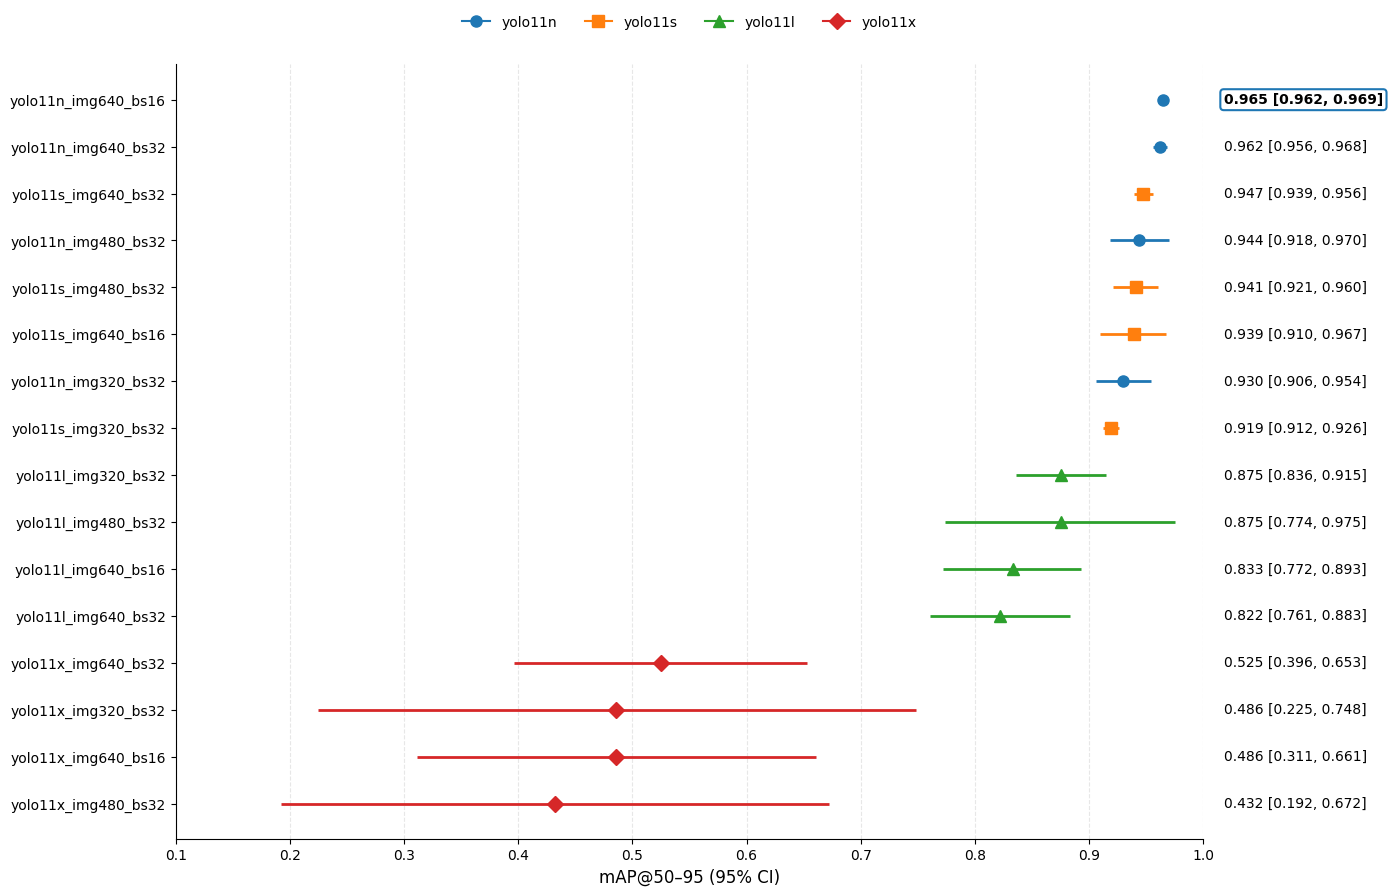

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DATOS
# =========================
rows = [
    ("yolo11n_img640_bs16", "yolo11n", 0.965, 0.962, 0.969),
    ("yolo11n_img640_bs32", "yolo11n", 0.962, 0.956, 0.968),
    ("yolo11s_img640_bs32", "yolo11s", 0.947, 0.939, 0.956),
    ("yolo11n_img480_bs32", "yolo11n", 0.944, 0.918, 0.970),
    ("yolo11s_img480_bs32", "yolo11s", 0.941, 0.921, 0.960),
    ("yolo11s_img640_bs16", "yolo11s", 0.939, 0.910, 0.967),
    ("yolo11n_img320_bs32", "yolo11n", 0.930, 0.906, 0.954),
    ("yolo11s_img320_bs32", "yolo11s", 0.919, 0.912, 0.926),
    ("yolo11l_img320_bs32", "yolo11l", 0.875, 0.836, 0.915),
    ("yolo11l_img480_bs32", "yolo11l", 0.875, 0.774, 0.975),
    ("yolo11l_img640_bs16", "yolo11l", 0.833, 0.772, 0.893),
    ("yolo11l_img640_bs32", "yolo11l", 0.822, 0.761, 0.883),
    ("yolo11x_img640_bs32", "yolo11x", 0.525, 0.396, 0.653),
    ("yolo11x_img320_bs32", "yolo11x", 0.486, 0.225, 0.748),
    ("yolo11x_img640_bs16", "yolo11x", 0.486, 0.311, 0.661),
    ("yolo11x_img480_bs32", "yolo11x", 0.432, 0.192, 0.672),
]

# =========================
# ESTILOS
# =========================
colors = {
    "yolo11n": "#1f77b4",
    "yolo11s": "#ff7f0e",
    "yolo11l": "#2ca02c",
    "yolo11x": "#d62728",
}

markers = {
    "yolo11n": "o",
    "yolo11s": "s",
    "yolo11l": "^",
    "yolo11x": "D",
}

# =========================
# PREPARAR DATOS
# =========================
labels = [r[0] for r in rows]
y = np.arange(len(rows))[::-1]

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(14, 9))

for i, (label, model, mean, low, high) in enumerate(rows):
    yy = y[i]

    ax.errorbar(
        mean,
        yy,
        xerr=[[mean - low], [high - mean]],
        fmt=markers[model],
        color=colors[model],
        markersize=8,
        linewidth=2,
        capsize=0,
    )

    # Texto fuera del eje X
    ax.text(
        1.02,
        yy,
        f"{mean:.3f} [{low:.3f}, {high:.3f}]",
        transform=ax.get_yaxis_transform(),
        va="center",
        fontsize=10,
        fontweight="bold" if i == 0 else "normal",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor=colors[model] if i == 0 else "none",
            linewidth=1.5 if i == 0 else 0,
        ) if i == 0 else None,
    )

# =========================
# CONFIGURACIÓN
# =========================
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)

ax.set_xlabel("mAP@50–95 (95% CI)", fontsize=12)

# Escala recomendada para que se vea toda la variabilidad
ax.set_xlim(0.10, 1.00)

ax.grid(axis="x", linestyle="--", alpha=0.3)

# Leyenda
for model in colors:
    ax.plot(
        [],
        [],
        marker=markers[model],
        color=colors[model],
        label=model,
        linestyle="-",
        markersize=8,
    )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=4,
    frameon=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Espacio para valores externos
plt.subplots_adjust(right=0.75)

plt.tight_layout()
plt.savefig("2_yolo_asistencia.png", dpi=300, bbox_inches="tight")
plt.show()